Introduccion y contexto del dataset

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Carga de Datos

In [85]:
#Carga Datset 1
df1 = pd.read_csv("../data/raw/diabetes.csv")
df1.head(20)

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
5,1008,248.0,94,69.0,3.6,4.81,Buckingham,34,male,71.0,190.0,large,132.0,86.0,NaN,NaN,36.0,42.0,195.0
6,1011,195.0,92,41.0,4.8,4.84,Buckingham,30,male,69.0,191.0,medium,161.0,112.0,161.0,112.0,46.0,49.0,720.0
7,1015,227.0,75,44.0,5.2,3.94,Buckingham,37,male,59.0,170.0,medium,NaN,NaN,NaN,NaN,34.0,39.0,1020.0
8,1016,177.0,87,49.0,3.6,4.84,Buckingham,45,male,69.0,166.0,large,160.0,80.0,128.0,86.0,34.0,40.0,300.0
9,1022,263.0,89,40.0,6.6,5.78,Buckingham,55,female,63.0,202.0,small,108.0,72.0,NaN,NaN,45.0,50.0,240.0


In [86]:
#calculo de la variable objetivo a partir de la hemoglobina A1c (Segun lo documentado en el dataset)
df1["target"] = (df1["glyhb"] >= 6.5).astype(int)


In [87]:
df1["target"].value_counts()

target
0    338
1     65
Name: count, dtype: int64

In [88]:
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
 19  target    403 non-null    int64  
dtypes: float64(13), int64(4), object

In [89]:
df1.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,target
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000,403.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000,0.161290
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953,0.368256
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000,0.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000,0.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000,0.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000,0.000000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000,1.000000


La variable objetivo original es continua.
Siguiendo el criterio clínico del dataset, se binarizó considerando valores ≥ 6.5 como presencia de la enfermedad (1) y valores < 6.5 como ausencia (0).
Esta transformación permite aplicar modelos de clasificación supervisada.

In [90]:
#Analisis de relacion para deducir sifnificado de bp.1s y bp.1d
(df1["bp.1s"] > df1["bp.1d"]).mean()


np.float64(0.9875930521091811)

Al obtener un resultado muy cercano a 1 podemos asumir que s > d lo cual nos dice que estos valores corresponden a la presion arterial sistolica y distolica

In [91]:
#Analisis estadístico de columnas de presión arterial
df1[["bp.1s", "bp.1d", "bp.2s", "bp.2d"]].describe()


,bp.1s,bp.1d,bp.2s,bp.2d
count,398.000000,398.000000,141.000000,141.000000
mean,136.904523,83.321608,152.382979,92.524823
std,22.741033,13.589227,21.712952,11.555198
min,90.000000,48.000000,110.000000,60.000000
25%,121.250000,75.000000,138.000000,84.000000
50%,136.000000,82.000000,149.000000,92.000000
75%,146.750000,90.000000,161.000000,100.000000
max,250.000000,124.000000,238.000000,124.000000


El dataset incluye dos mediciones de presión arterial (sistólica y diastólica). 
Esto confirmado mediante su relacion y los rangos promedios que se calculan en el analisis descriptivo
siendo estos determinantes que: s > d (La presion sistolica es mayor que la distolica) y 
El promedio del rango de la presion sistolica ~90–180 y la presion distolica ~60–120
La decisión final de modelado se tomará tras evaluar su aporte predictivo.

In [92]:
#Filtar valores no numéricos
bp_cols = ["bp.1s", "bp.1d", "bp.2s", "bp.2d"]
df1[bp_cols] = df1[bp_cols].apply(pd.to_numeric, errors="coerce")

In [93]:
#Verificacion de nulos
df1[bp_cols].isnull().sum()

bp.1s      5
bp.1d      5
bp.2s    262
bp.2d    262
dtype: int64

Las variables correspondientes a la segunda toma de presión arterial (`bp.2s`, `bp.2d`)
presentan más del 65% de valores faltantes.  
Dado el tamaño reducido del dataset (~400 registros) y la imposibilidad de imputación
clínicamente justificada, estas variables fueron descartadas para evitar sesgos y pérdida
de estabilidad en los modelos predictivos.

In [94]:
df1 = df1.drop(columns=["bp.2s", "bp.2d"])

Al analizar a profundidad el dataset hallamos que las medidas de estatura y peso corporal no esta en unidades metricas, estan en pulgadas y libras respectivamente, se decide realizar la conversion a unidades metricas para el proximo calculo del BMI

In [98]:
df1["height_m"] = df1["height"] * 0.0254
df1["weight_kg"] = df1["weight"] * 0.453592

In [ ]:
#Verificacion estadistica del calulo de las nuevas variables
df1[["height", "height_m", "weight", "weight_kg"]].describe()


,height,height_m,weight,weight_kg
count,398.000000,398.000000,402.000000,402.000000
mean,66.020101,1.676911,177.592040,80.554329
std,3.918515,0.099530,40.340666,18.298203
min,52.000000,1.320800,99.000000,44.905608
25%,63.000000,1.600200,151.000000,68.492392
50%,66.000000,1.676400,172.500000,78.244620
75%,69.000000,1.752600,200.000000,90.718400
max,76.000000,1.930400,325.000000,147.417400


In [101]:
#Calculo de IMC(BMI)
df1["bmi"] = df1["weight_kg"] / (df1["height_m"] ** 2)

In [102]:
df1["bmi"].describe()


count    397.000000
mean      28.787396
std        6.606538
min       15.204780
25%       24.128995
50%       27.802690
75%       32.239496
max       55.785505
Name: bmi, dtype: float64

Las variables antropométricas originales se encontraban en unidades imperiales
(pulgadas y libras). Se realizó la conversión a unidades métricas (metros y kilogramos)
para garantizar consistencia y permitir el cálculo del Índice de Masa Corporal (BMI).
El BMI fue incorporado como variable derivada clínicamente estandarizada.
Y realizo la eliminacion de variables no relevantes para el estudio.

In [103]:
df1 = df1.drop(columns=["height", "weight", "waist", "hip","location", "frame"])

In [125]:
df1.head(20)

,id,chol,stab.glu,hdl,ratio,glyhb,age,gender,bp.1s,bp.1d,time.ppn,target,height_m,weight_kg,bmi,gender_encoded
0,1000,203.0,82,56.0,3.6,4.31,46,female,118.0,59.0,720.0,0,1.5748,54.884632,22.130944,0
1,1001,165.0,97,24.0,6.9,4.44,29,female,112.0,68.0,360.0,0,1.6256,98.883056,37.419200,0
2,1002,228.0,92,37.0,6.2,4.64,58,female,190.0,92.0,180.0,0,1.5494,116.119552,48.370241,0
3,1003,78.0,93,12.0,6.5,4.63,67,male,110.0,50.0,480.0,0,1.7018,53.977448,18.637828,1
4,1005,249.0,90,28.0,8.9,7.72,64,male,138.0,80.0,300.0,1,1.7272,83.007336,27.824747,1
5,1008,248.0,94,69.0,3.6,4.81,34,male,132.0,86.0,195.0,0,1.8034,86.182480,26.499328,1
6,1011,195.0,92,41.0,4.8,4.84,30,male,161.0,112.0,720.0,0,1.7526,86.636072,28.205457,1
7,1015,227.0,75,44.0,5.2,3.94,37,male,NaN,NaN,1020.0,0,1.4986,77.110640,34.335459,1
8,1016,177.0,87,49.0,3.6,4.84,45,male,160.0,80.0,300.0,0,1.7526,75.296272,24.513643,1
9,1022,263.0,89,40.0,6.6,5.78,55,female,108.0,72.0,240.0,0,1.6002,91.625584,35.782298,0


In [124]:
#codificacion de genero
df1["gender_encoded"] = df1["gender"].map({
    "male": 1,
    "female": 0
})

In [126]:
df1["gender_encoded"].value_counts(dropna=False)


gender_encoded
0    234
1    169
Name: count, dtype: int64

La variable categórica `gender` fue codificada de forma binaria
(0 = femenino, 1 = masculino) para permitir su inclusión
en el análisis de correlación y modelos de clasificación.

In [119]:
#analisis de correlacion entre variables numericas
num_cols_scaled = [
    "age",
    "chol",
    "hdl",
    "ratio",
    "glyhb",
    "stab.glu",
    "bp.1s",
    "bp.1d",
    "height_m",
    "weight_kg",
    "bmi",
    "time.ppn"
]
num_cols_corr = num_cols_scaled + ["gender_encoded"]

Las variables numéricas fueron estandarizadas mediante StandardScaler,
obteniendo una media cercana a cero y desviación estándar unitaria.
La aparición de valores en notación científica responde a la precisión
numérica de punto flotante y no representa una distorsión de los datos.

In [ ]:
scaler = StandardScaler()
df_scaled = df1.copy()
df_scaled[num_cols_scaled] = scaler.fit_transform(df1[num_cols_scaled])

In [121]:
df_scaled[num_cols_scaled].describe()

,age,chol,hdl,ratio,glyhb,stab.glu,bp.1s,bp.1d,height_m,weight_kg,bmi,time.ppn
count,4.030000e+02,4.020000e+02,4.020000e+02,4.020000e+02,3.900000e+02,4.030000e+02,3.980000e+02,3.980000e+02,3.980000e+02,4.020000e+02,3.970000e+02,400.000000
mean,-1.498663e-16,-1.833801e-16,-1.502391e-16,-1.855895e-16,-1.958547e-16,1.410507e-16,7.810614e-17,4.195416e-16,1.856695e-15,-3.888542e-16,-2.818904e-16,0.000000
std,1.001243e+00,1.001246e+00,1.001246e+00,1.001246e+00,1.001285e+00,1.001243e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001246e+00,1.001262e+00,1.001252
min,-1.709488e+00,-2.925097e+00,-2.229857e+00,-1.750930e+00,-1.299168e+00,-1.106803e+00,-2.065146e+00,-2.602508e+00,-3.582415e+00,-1.950636e+00,-2.058530e+00,-1.087646
25%,-7.887952e-01,-6.498223e-01,-7.218358e-01,-7.658425e-01,-5.401435e-01,-4.842876e-01,-6.892486e-01,-6.131388e-01,-7.716959e-01,-6.600084e-01,-7.060094e-01,-0.812702
50%,-1.136206e-01,-8.663551e-02,-2.578294e-01,-1.863796e-01,-3.347605e-01,-3.333749e-01,-3.982498e-02,-9.737651e-02,-5.136079e-03,-1.263833e-01,-1.492382e-01,-0.327507
75%,8.070720e-01,4.990788e-01,4.961810e-01,5.089762e-01,4.567838e-03,-1.268528e-02,4.334838e-01,4.920661e-01,7.614237e-01,5.561605e-01,5.231872e-01,0.570105
max,2.771216e+00,5.297431e+00,4.034230e+00,8.563512e+00,4.697123e+00,5.250397e+00,4.979449e+00,2.997197e+00,2.550063e+00,3.658632e+00,4.091731e+00,3.942213


Se empleó una matriz de correlación de Pearson sobre variables numéricas
previamente estandarizadas, con el fin de analizar relaciones lineales
y detectar posibles problemas de colinealidad antes del entrenamiento
de los modelos de clasificación.

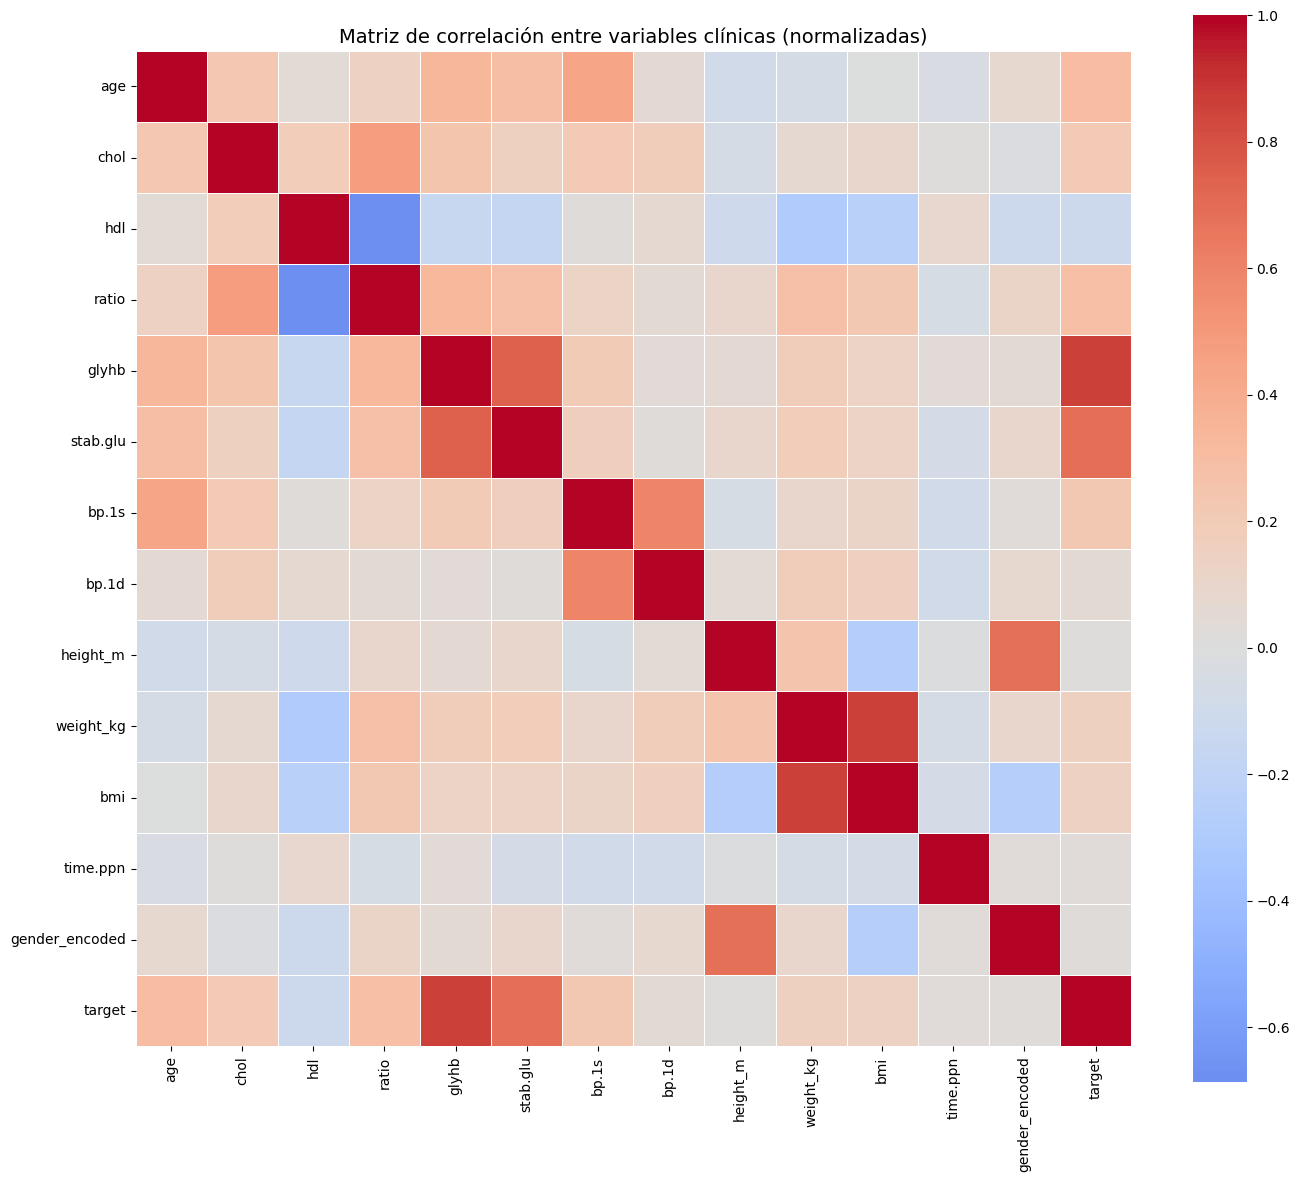

In [127]:
# Variables a incluir en la correlación
corr_cols = num_cols_corr + ["target"]

# Cálculo de la matriz de correlación
corr_matrix = df_scaled[corr_cols].corr()

# Visualización
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables clínicas (normalizadas)", fontsize=14)
plt.tight_layout()
plt.show()

Despues de realizar el analisis de las variables presentes en este dataset se decide conservar las siguientes columnas:
"gender", "glyhb", "stab.glu", "age", "ratio", "bp.1s", "bmi"

In [128]:
#Carga Datset 2
df2 = pd.read_csv("../data/raw/diabetes_prediction_dataset.csv")
df2.head(20)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [129]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
#Codificacion de genero
df2["gender_encoded"] = df2["gender"].map({
    "Male": 1,
    "Female": 0
})


In [ ]:
df2 = df2.drop(columns=[
    "hypertension",
    "heart_disease",
    "smoking_history"
])

In [133]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   gender         100000 non-null  object 
 1   age            100000 non-null  float64
 2   bmi            100000 non-null  float64
 3   hbA1c          100000 non-null  float64
 4   blood_glucose  100000 non-null  int64  
 5   target         100000 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 4.6+ MB


In [132]:
df2 = df2.rename(columns={"diabetes": "target",
    "HbA1c_level": "hbA1c",
    "blood_glucose_level": "blood_glucose"})


In [97]:
#Carga Datset 3
df3 = pd.read_csv("../data/raw/Training.csv")
df3.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Inspección general

Valores faltantes

Distribución de variables

Correlación entre variables

Observaciones relevantes

Implicaciones para el modelo de datos (ClinicalRecord)